## Plotting OLS results vs Correlation results

In [1]:
#read in the results from correlation analysis, then aggregate
import pandas as pd

cor_res_100kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_ct_time_100kb_results.csv")
cor_res_100kb.head()

# classify every peak–gene pair into one of three categories
def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_res_100kb["category"] = cor_res_100kb.apply(classify_pair, axis=1)

#aggregate the number of significant peaks per gene and category  
agg_cor_100kb_df = (
    cor_res_100kb
    .dropna(subset=["correlation", "padj", "category"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)
agg_cor_100kb_df.head()

,window,gene,category,count
0,100kb,a1cf,non-significant,67
1,100kb,a1cf,sig. positive,28
2,100kb,a2ml,non-significant,70
3,100kb,a2ml,sig. positive,7
4,100kb,aaas,non-significant,93


In [3]:
#read in the saved all_ols_dfs dataframe to confirm it was saved correctly
ols_res_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_range_df_ct_time.csv")
ols_res_100kb = ols_res_df[ols_res_df["window"] == "100kb"].copy()
ols_res_100kb.head()

#aggregate the number of significant peaks per gene and category for OLS results
agg_ols_100kb_df = (
    ols_res_100kb
    .dropna(subset=["pval", "coef", "category"])
    .groupby(["window", "gene", "category"]) 
    .size()
    .reset_index(name="count")
)
agg_ols_100kb_df.head()

,window,gene,category,count
0,100kb,a1cf,non-significant,89
1,100kb,a1cf,sig. negative,2
2,100kb,a1cf,sig. positive,4
3,100kb,a2ml,non-significant,77
4,100kb,aaas,non-significant,102


In [4]:
#merge the two aggregated dataframes on window, gene to compare the number of significant peaks per gene and category between correlation and OLS results

#rename the count column in agg_cor_100kb_df to count_cor to avoid confusion with the count column in agg_ols_100kb_df
agg_cor_100kb_df["count_cor"] = agg_cor_100kb_df['count']
agg_ols_100kb_df["count_ols"] = agg_ols_100kb_df['count']

agg_merged_df = pd.merge(
    agg_cor_100kb_df,
    agg_ols_100kb_df,
    on=["window", "gene", "category"],
    how="outer",
)
agg_merged_df.head() 

,window,gene,category,count_x,count_cor,count_y,count_ols
0,100kb,a1cf,non-significant,67.0,67.0,89.0,89.0
1,100kb,a1cf,sig. negative,NaN,NaN,2.0,2.0
2,100kb,a1cf,sig. positive,28.0,28.0,4.0,4.0
3,100kb,a2ml,non-significant,70.0,70.0,77.0,77.0
4,100kb,a2ml,sig. positive,7.0,7.0,NaN,NaN


/tmp/ipykernel_3452293/3302853467.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_sig_df["n_genes"] = plot_sig_df.groupby(


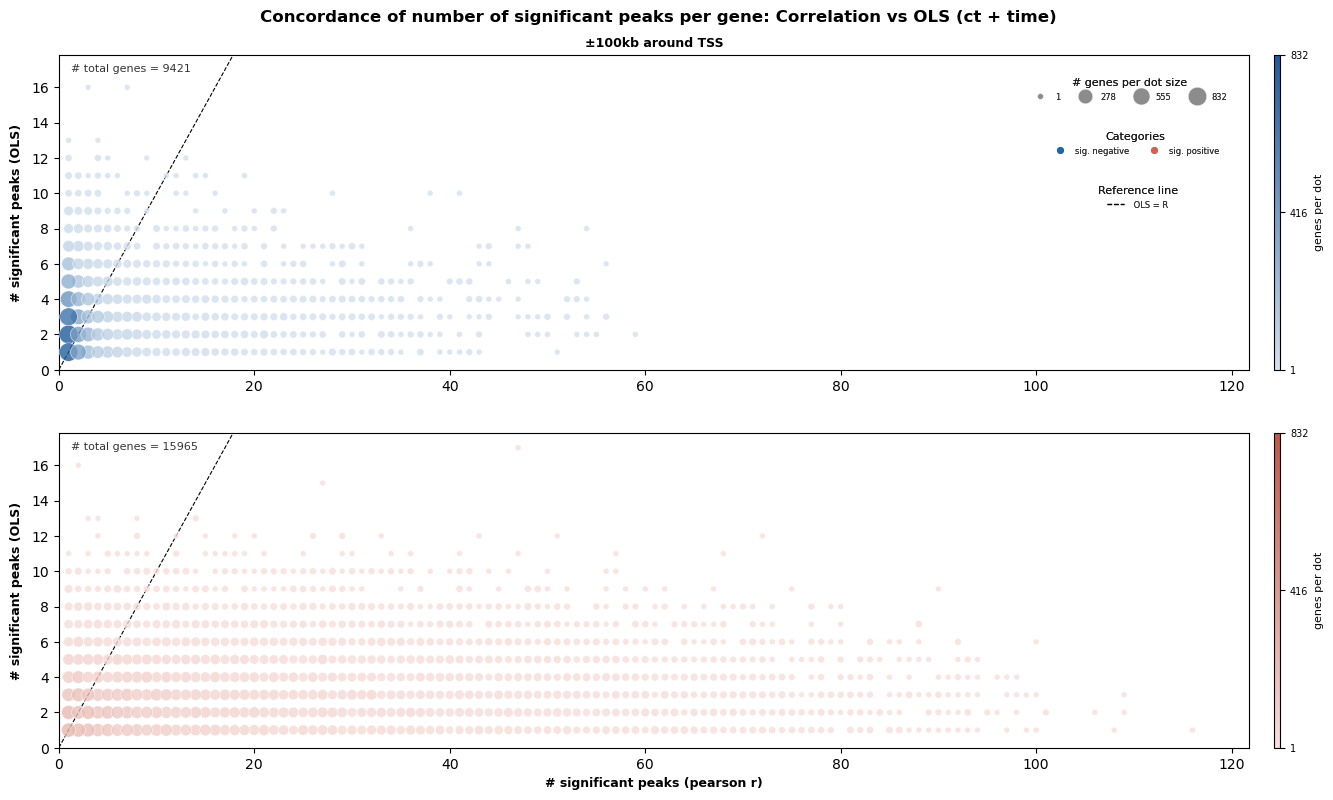

In [5]:
#plot the number of significant peaks per gene in correlation vs OLS results, colored by category and faceted by window & category
from tkinter import font

from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_sig_df = plot_df[plot_df["category"] != "non-significant"].copy()

# Count genes per (count_cor, count_ols, window, category) position
plot_sig_df["n_genes"] = plot_sig_df.groupby(
    ["window", "category", "count_cor", "count_ols"] 
)["gene"].transform("count")

category_base_colors = {
    "sig. negative": "#2166ac",
    "sig. positive": "#d6604d",
}
category_order = ["sig. negative", "sig. positive"]
windows = ["100kb"]

# Deduplicate to one row per unique (x, y, window, category) position
plot_dedup = plot_sig_df.drop_duplicates(
    subset=["count_cor", "count_ols", "window", "category"]
).copy()

# Global n_genes range for consistent size/color scaling
n_min = plot_dedup["n_genes"].min()
n_max = plot_dedup["n_genes"].max()

def make_alpha_cmap(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    light = (1 - (1 - r) * 0.20, 1 - (1 - g) * 0.20, 1 - (1 - b) * 0.20)
    dark  = (r * 0.9, g * 0.9, b * 0.9)
    return mcolors.LinearSegmentedColormap.from_list("cat_cmap", [light, dark])
# ↑ removed hex_color midpoint — now light=n_min, dark=n_max, linear between them
def size_scale(n, n_min, n_max, s_min=18, s_max=180):
    """Map gene count to marker area (sqrt scaling feels more linear visually)."""
    if n_max == n_min:
        return (s_min + s_max) / 2
    return s_min + (s_max - s_min) * ((n - n_min) / (n_max - n_min)) ** 0.5
# plot: rows = categories, cols = windows, points colored by category 
fig, axes = plt.subplots(
    len(category_order), len(windows),
    figsize=(16, 9),
    sharex=False, sharey=True,
)

axis_max = plot_sig_df[["count_cor", "count_ols"]].max().max() 

for row_i, category in enumerate(category_order):
    cmap = make_alpha_cmap(category_base_colors[category])
    norm = Normalize(vmin=n_min, vmax=n_max) 
     # ✓ one colorbar per row, attached to the rightmost axis
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=axes[row_i],   # spans all axes in this row
        orientation="vertical",
        fraction=0.02,        # thin bar
        pad=0.02,
        aspect=50,
    )
    cbar.set_label("genes per dot", fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    # tick at n_min, midpoint, n_max
    cbar.set_ticks([n_min, (n_min + n_max) // 2, n_max])

    for col_i, window in enumerate(windows):
        ax = axes[row_i]
        data = plot_dedup[
            (plot_dedup["window"] == window) &
            (plot_dedup["category"] == category)
        ]

        if not data.empty:
            sizes  = data["n_genes"].apply(lambda n: size_scale(n, n_min, n_max))
            colors = cmap(norm(data["n_genes"]))

            ax.scatter(
                data["count_cor"], data["count_ols"],
                c=colors, s = sizes,
                edgecolors="w", linewidths=0.4, zorder=3, alpha =0.8, 
            )

        ax.plot([0, axis_max], [0, axis_max],
                color="k", linestyle="--", linewidth=0.8, zorder=0)
        ax.set_xlim(0, axis_max*1.05)
        ax.set_ylim(0, plot_sig_df[ "count_ols"].max()*1.05)

        if row_i == 0:
            ax.set_title("±100kb around TSS", fontsize=9, fontweight="bold")
        if col_i == 0:
            ax.set_ylabel("# significant peaks (OLS)", fontsize=9, labelpad=6,fontweight="bold")
        else:
            ax.set_ylabel("")
        if row_i == len(category_order) - 1:
            ax.set_xlabel("# significant peaks (pearson r)", fontsize=9,fontweight="bold")
        else:
            ax.set_xlabel("")

        n_total = data["n_genes"].sum()
        ax.text(0.01,0.97, f"# total genes = {n_total}", transform=ax.transAxes,
                ha="left", va="top", fontsize=8, color="0.2") #on the right side to avoid overlap with y-axis
        
# ── Legend: size scale (two columns) ────────────────────────────────────────────
legend_counts = np.linspace(n_min, n_max, 4).astype(int)

size_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markersize=np.sqrt(size_scale(n, n_min, n_max)),
           markerfacecolor="0.55", markeredgecolor="w", markeredgewidth=0.4,
           label=str(n))
    for n in legend_counts
]

size_legend = fig.legend(
    handles=size_handles,
    title="# genes per dot size",
    loc="lower right",
    bbox_to_anchor=(0.86, 0.82),
    ncol= 4,
    frameon=False,
    fontsize=6,
    title_fontsize=8,
)

# bold + center the size legend's title (it's a separate Text object, easier to control)
size_legend.get_title().set_fontweight("roman")
size_legend.get_title().set_color("0.1")
size_legend.get_title().set_ha("center")
for text in size_legend.get_texts():
    text.set_color("0.2")
# ── Legend: categories ─────────────────────────────────────────────────────────
category_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=category_base_colors[c],
           markeredgecolor=category_base_colors[c],
           markersize=4, label=c)
    for c in category_order
]

cat_legend = fig.legend(
    handles=category_handles,
    title="Categories",
    loc="lower right",
    bbox_to_anchor=(0.855, 0.76),
    ncol=2,
    frameon=False,
    fontsize=6,
    title_fontsize=8,
)
# bold + center the cat legend's title (it's a separate Text object, easier to control)
cat_legend.get_title().set_fontweight("roman")
cat_legend.get_title().set_ha("center")
cat_legend.get_title().set_color("0.1")
for text in cat_legend.get_texts():
    text.set_color("0.2")


# ── Legend: diagonal line ─────────────────────────────────────────────────────
line_handle = [
    Line2D([0], [0], color="k", linestyle="--", linewidth=0.9, label=" OLS = R")
]

line_legend = fig.legend(
    handles=line_handle,
    title="Reference line",
    loc="lower right",
    bbox_to_anchor=(0.829, 0.7),
    frameon=False,
    fontsize=6,
    title_fontsize=8,
)
# bold + center the size legend's title (it's a separate Text object, easier to control)
line_legend.get_title().set_fontweight("roman")
line_legend.get_title().set_color("0.1")
line_legend.get_title().set_ha("center")
for text in line_legend.get_texts():
    text.set_color("0.2")

fig.add_artist(cat_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(size_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(line_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)

plt.suptitle(
    "Concordance of number of significant peaks per gene: Correlation vs OLS (ct + time)",
    fontsize=12, y= 0.93, fontweight="bold",
)

plt.show()



/tmp/ipykernel_3452293/418096985.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_non_sig_df["n_genes"] = plot_non_sig_df.groupby(


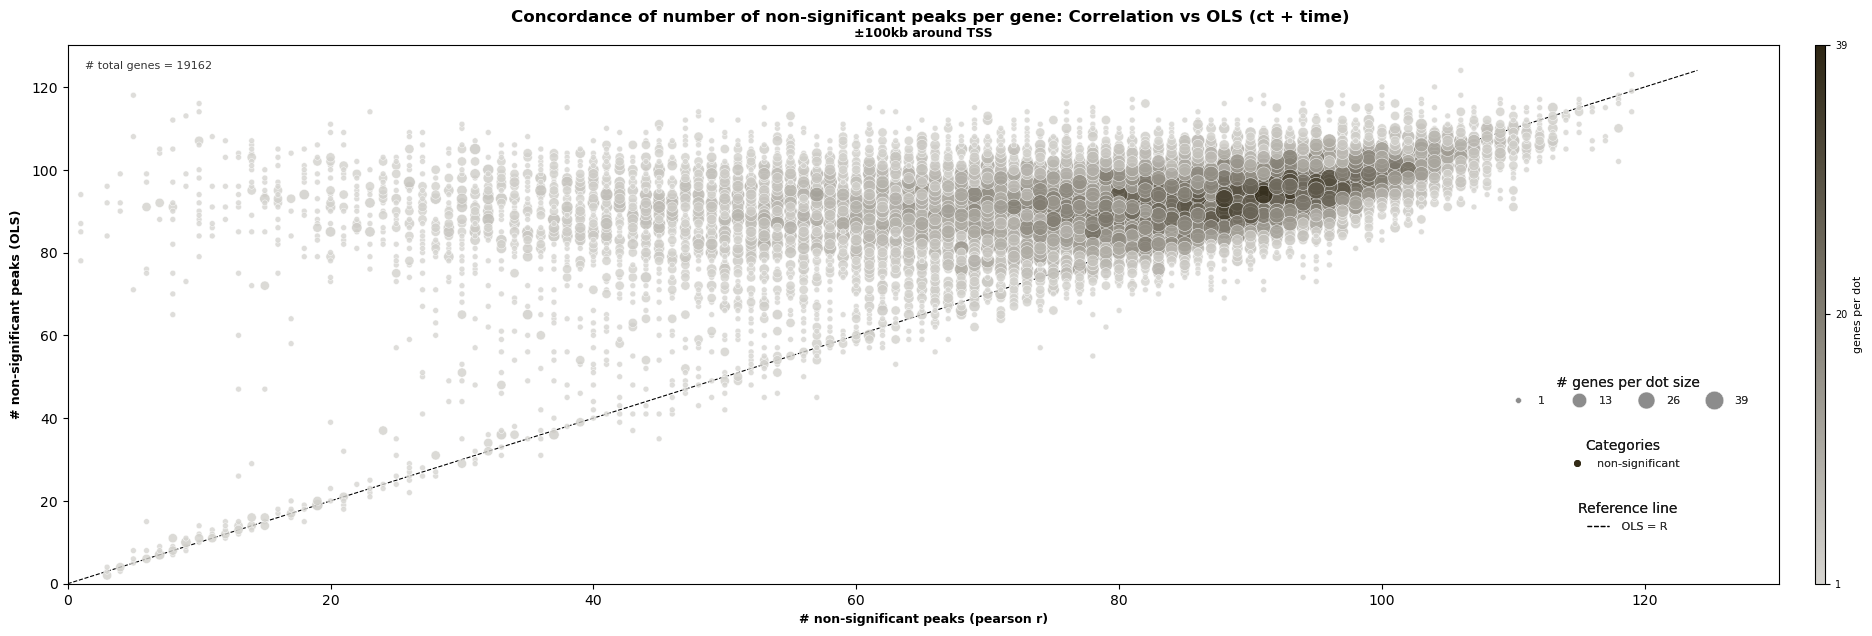

In [6]:
#plot the number of significant peaks per gene in correlation vs OLS results, colored by category and faceted by window & category
from tkinter import font

from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_non_sig_df = plot_df[plot_df["category"] == "non-significant"].copy()

# Count genes per (count_cor, count_ols, window, category) position
plot_non_sig_df["n_genes"] = plot_non_sig_df.groupby(
    ["window", "category", "count_cor", "count_ols"] 
)["gene"].transform("count")

category_base_colors = {
    "non-significant": "#332b17",
}
category_order = ["non-significant"]
windows = ["100kb"]

# Deduplicate to one row per unique (x, y, window, category) position
plot_dedup = plot_non_sig_df.drop_duplicates(
    subset=["count_cor", "count_ols", "window", "category"]
).copy()

# Global n_genes range for consistent size/color scaling
n_min = plot_dedup["n_genes"].min()
n_max = plot_dedup["n_genes"].max()

def make_alpha_cmap(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    light = (1 - (1 - r) * 0.20, 1 - (1 - g) * 0.20, 1 - (1 - b) * 0.20)
    dark  = (r * 0.9, g * 0.9, b * 0.9)
    return mcolors.LinearSegmentedColormap.from_list("cat_cmap", [light, dark])
# ↑ removed hex_color midpoint — now light=n_min, dark=n_max, linear between them
def size_scale(n, n_min, n_max, s_min=18, s_max=180):
    """Map gene count to marker area (sqrt scaling feels more linear visually)."""
    if n_max == n_min:
        return (s_min + s_max) / 2
    return s_min + (s_max - s_min) * ((n - n_min) / (n_max - n_min)) ** 0.5
# plot: rows = categories, cols = windows, points colored by category 
fig, axes = plt.subplots(
    len(category_order), len(windows),
    figsize=(23, 7),
    sharex=False, sharey=True,
)

axis_max = plot_non_sig_df[["count_cor", "count_ols"]].max().max() 

for row_i, category in enumerate(category_order):
    cmap = make_alpha_cmap(category_base_colors[category])
    norm = Normalize(vmin=n_min, vmax=n_max) 
     # ✓ one colorbar per row, attached to the rightmost axis
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax= axes,  # spans all axes in this row
        orientation="vertical",
        fraction=0.02,        # thin bar
        pad=0.02,
        aspect=50,
    )
    cbar.set_label("genes per dot", fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    # tick at n_min, midpoint, n_max
    cbar.set_ticks([n_min, (n_min + n_max) // 2, n_max])

    for col_i, window in enumerate(windows):
        ax = axes
        data = plot_dedup[
            (plot_dedup["window"] == window) &
            (plot_dedup["category"] == category)
        ]

        if not data.empty:
            sizes  = data["n_genes"].apply(lambda n: size_scale(n, n_min, n_max))
            colors = cmap(norm(data["n_genes"]))

            ax.scatter(
                data["count_cor"], data["count_ols"],
                c=colors, s = sizes,
                edgecolors="w", linewidths=0.4, zorder=3, alpha =0.8, 
            )

        ax.plot([0, axis_max], [0, axis_max],
                color="k", linestyle="--", linewidth=0.8, zorder=0)
        ax.set_xlim(0, axis_max*1.05)
        ax.set_ylim(0, plot_non_sig_df[ "count_ols"].max()*1.05)

        if row_i == 0:
            ax.set_title("±100kb around TSS", fontsize=9, fontweight="bold")
        if col_i == 0:
            ax.set_ylabel("# non-significant peaks (OLS)", fontsize=9, labelpad=6,fontweight="bold")
        else:
            ax.set_ylabel("")
        if row_i == len(category_order) - 1:
            ax.set_xlabel("# non-significant peaks (pearson r)", fontsize=9,fontweight="bold")
        else:
            ax.set_xlabel("")

        n_total = data["n_genes"].sum()
        ax.text(0.01,0.97, f"# total genes = {n_total}", transform=ax.transAxes,
                ha="left", va="top", fontsize=8, color="0.2") #on the right side to avoid overlap with y-axis
        
# ── Legend: size scale (two columns) ────────────────────────────────────────────
legend_counts = np.linspace(n_min, n_max, 4).astype(int)

size_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markersize=np.sqrt(size_scale(n, n_min, n_max)),
           markerfacecolor="0.55", markeredgecolor="w", markeredgewidth=0.4,
           label=str(n))
    for n in legend_counts
]

size_legend = fig.legend(
    handles=size_handles,
    title="# genes per dot size",
    loc="lower right",
    bbox_to_anchor=(0.86, 0.35),
    ncol= 4,
    frameon=False,
    fontsize=8,
    title_fontsize=10,
)

# bold + center the size legend's title (it's a separate Text object, easier to control)
size_legend.get_title().set_fontweight("roman")
size_legend.get_title().set_color("0.1")
size_legend.get_title().set_ha("center")
for text in size_legend.get_texts():
    text.set_color("0.2")
# ── Legend: categories ─────────────────────────────────────────────────────────
category_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=category_base_colors[c],
           markeredgecolor=category_base_colors[c],
           markersize=4, label=c)
    for c in category_order
]

cat_legend = fig.legend(
    handles=category_handles,
    title="Categories",
    loc="lower right",
    bbox_to_anchor=(0.83, 0.26),
    ncol=2,
    frameon=False,
    fontsize=8,
    title_fontsize=10,
)
# bold + center the cat legend's title (it's a separate Text object, easier to control)
cat_legend.get_title().set_fontweight("roman")
cat_legend.get_title().set_ha("center")
cat_legend.get_title().set_color("0.1")
for text in cat_legend.get_texts():
    text.set_color("0.2")


# ── Legend: diagonal line ─────────────────────────────────────────────────────
line_handle = [
    Line2D([0], [0], color="k", linestyle="--", linewidth=0.9, label=" OLS = R")
]

line_legend = fig.legend(
    handles=line_handle,
    title="Reference line",
    loc="lower right",
    bbox_to_anchor=(0.829, 0.17),
    frameon=False,
    fontsize=8,
    title_fontsize=10,
)
# bold + center the size legend's title (it's a separate Text object, easier to control)
line_legend.get_title().set_fontweight("roman")
line_legend.get_title().set_color("0.1")
line_legend.get_title().set_ha("center")
for text in line_legend.get_texts():
    text.set_color("0.2")

fig.add_artist(cat_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(size_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(line_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)

plt.suptitle(
    "Concordance of number of non-significant peaks per gene: Correlation vs OLS (ct + time)",
    fontsize=12, y= 0.93, fontweight="bold",
)

plt.show()



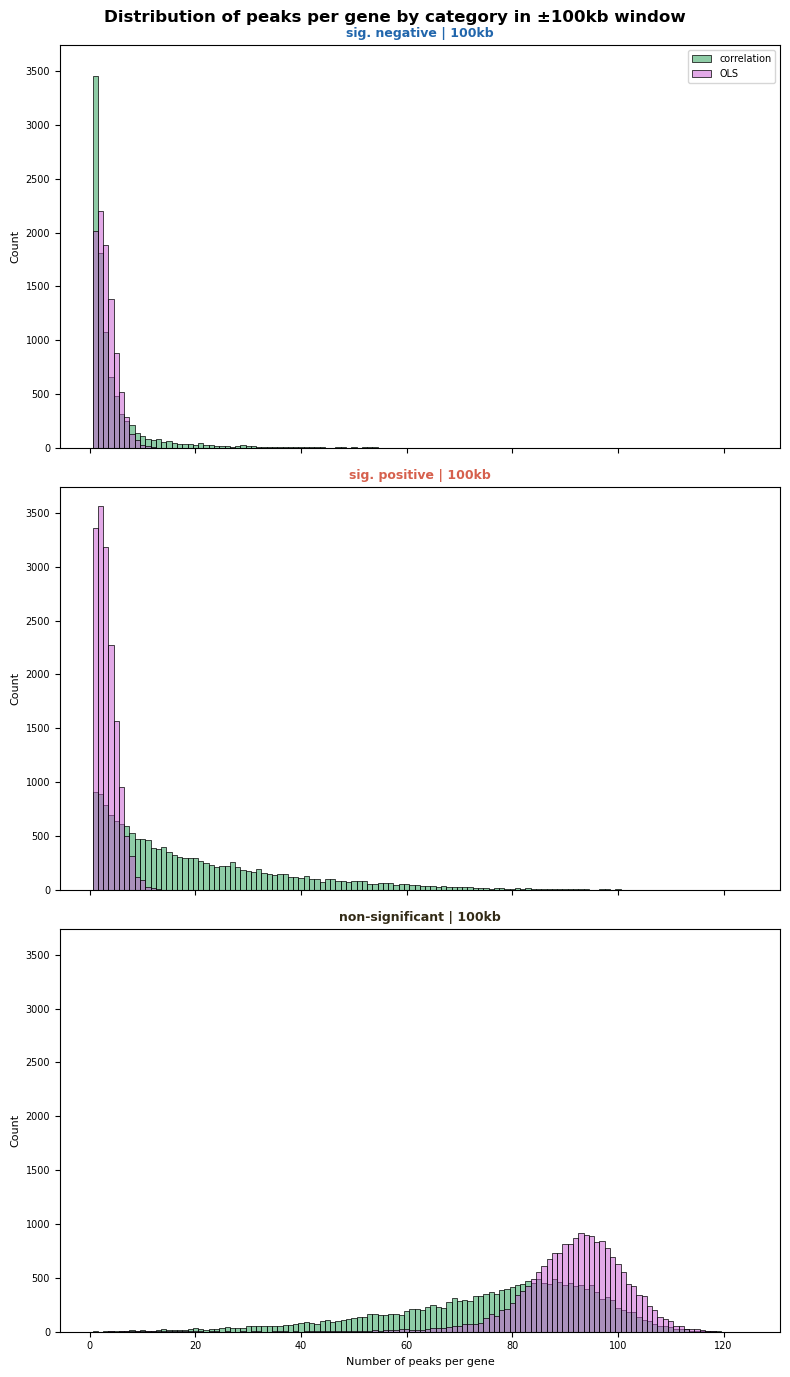

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_sig_df = plot_df.copy()
plot_sig_df["category"] = pd.Categorical(
    plot_sig_df["category"],
    categories=["sig. negative", "sig. positive", "non-significant"],
    ordered=True,
)

# Deduplicate to one row per unique (x, y, window, category) position
plot_dedup = plot_sig_df.drop_duplicates(
    subset=["count_cor", "count_ols", "window", "category"]
).copy()
category_order = ["sig. negative", "sig. positive", "non-significant"]
category_base_colors = {
    "sig. negative": "#2166ac",
    "sig. positive": "#d6604d",
    "non-significant": "#332b17",
}
window_labels = ["100kb"]
method_colors = {"correlation": "#1e9b4e", "OLS": "#c755d1"}

fig, axes = plt.subplots(len(category_order),1, figsize=(8, 14), sharex=True, sharey=True)

for row_idx, win in enumerate(window_labels):
    win_data = plot_sig_df[plot_sig_df["window"] == win]

    for col_idx, cat in enumerate(category_order):
        ax = axes[col_idx]
        cat_data = win_data[win_data["category"] == cat]

        combined_counts = pd.concat([win_data["count_cor"], win_data["count_ols"]]).dropna()
        if combined_counts.empty:
            ax.set_axis_off()
            continue

        bin_edges = np.linspace(combined_counts.min(), combined_counts.max(), 16)
        if np.unique(bin_edges).size < 2:
            bin_edges = np.array([combined_counts.min() - 0.5, combined_counts.max() + 0.5])

        # Plot correlation histogram
        sns.histplot(
            cat_data["count_cor"],
            #bins=bin_edges,
            alpha=0.5,
            label="correlation",
            color=method_colors["correlation"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax

        )
        # Plot OLS histogram
        sns.histplot(
            cat_data["count_ols"],
            #bins=bin_edges,
            alpha=0.5,
            label="OLS",
            color=method_colors["OLS"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax
        )

        ax.set_xlabel("Number of peaks per gene", fontsize=8)
        ax.set_ylabel("Count", fontsize=8)
        ax.set_title(f"{cat} | {win}", fontsize=9, fontweight="bold", color=category_base_colors.get(cat, "k"))
        ax.tick_params(labelsize=7)

        if row_idx == 0 and col_idx == 0:
            ax.legend(loc="upper right", fontsize=7)

fig.suptitle("Distribution of peaks per gene by category in ±100kb window", fontsize=12, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

## Gene annotation with number of assigned peaks

In [1]:
#load the data 
import pandas as pd
window_assignment = pd.read_csv('/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/20 windows/combined_gene_peak_assignments_100kb.csv')
window_assignment.head()

,gene_id,assigned_peaks
0,a1cf,"['12-6186644-6187111', '12-6190483-6191143', '..."
1,a2ml,"['15-21143884-21144162', '15-21033797-21034001..."
2,aaas,"['9-323370-323691', '9-209853-211311', '9-2304..."
3,aacs,"['5-18949828-18950713', '5-18811696-18812645',..."
4,aadac,"['15-1052335-1053001', '15-1029184-1030074', '..."


In [2]:
window_assignment[window_assignment['gene_id'] == "zgc:171695"]["assigned_peaks"].values[0]

"['7-3094014-3094231', '7-3024771-3024974', '7-2936068-2936742', '7-3098511-3099164']"

In [3]:
# count the number of peaks assigned to each gene
#make the assigned_peaks column a list of peaks instead of a string
window_assignment["assigned_peaks"] = window_assignment["assigned_peaks"].apply(lambda x: x.split(",") if pd.notnull(x) else [])
window_assignment["num_assigned_peaks"] = window_assignment["assigned_peaks"].apply(len)
peak_counts = window_assignment[["gene_id", "num_assigned_peaks"]]
peak_counts.head()

,gene_id,num_assigned_peaks
0,a1cf,95
1,a2ml,77
2,aaas,110
3,aacs,88
4,aadac,100


In [4]:
peak_counts[peak_counts["num_assigned_peaks"] == 4]["gene_id"]

13764    si:ch211-237a4.2
14679      si:dkey-51d8.1
18870          zgc:171695
18945          zgc:174314
Name: gene_id, dtype: object

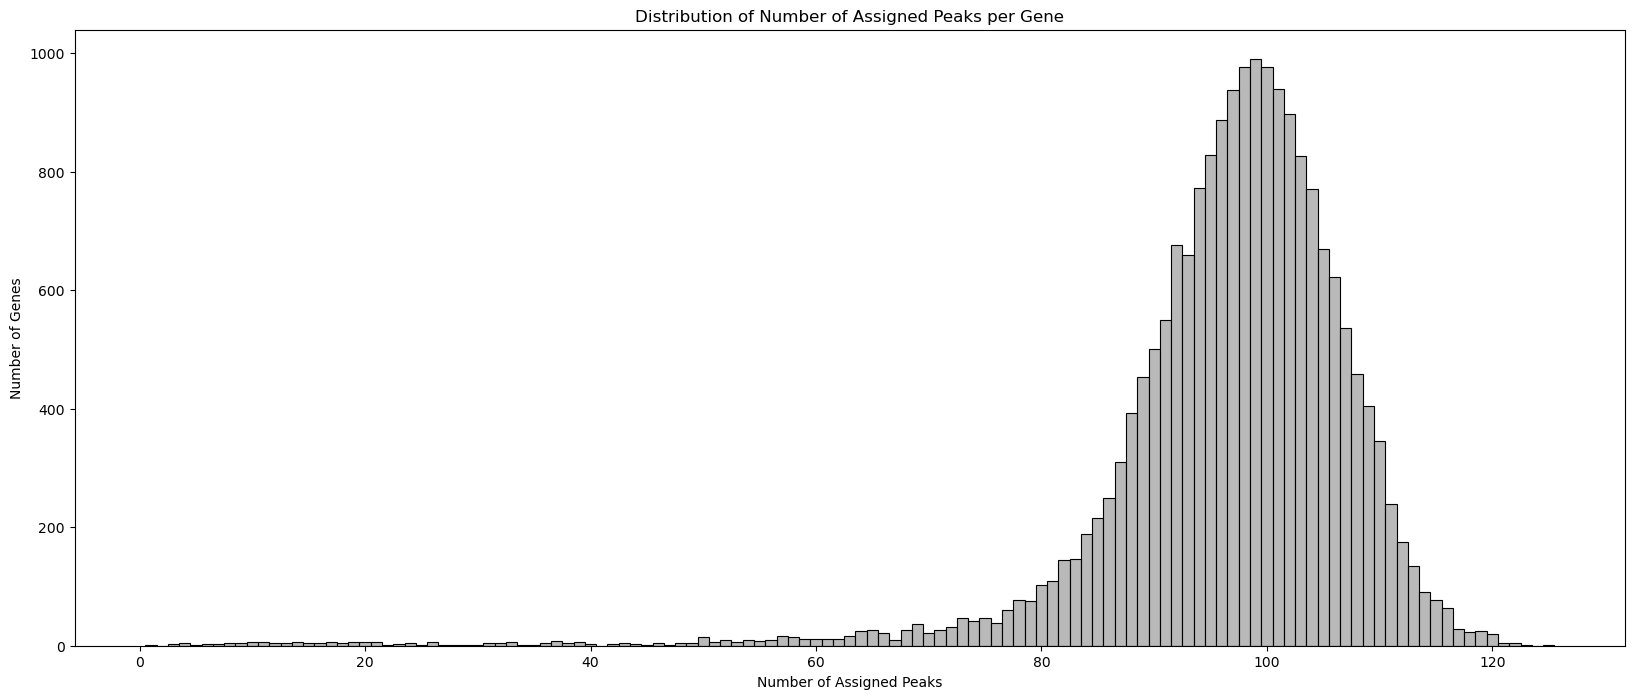

In [5]:
#plot the num_assigned_peaks column as a histogram
import matplotlib.pyplot as plt
import seaborn as sns

#make bin sizes equally spaced
plt.figure(figsize=(20, 8))
sns.histplot(peak_counts["num_assigned_peaks"], bins=range(0, peak_counts["num_assigned_peaks"].max() + 1), edgecolor="black", color="#a2a2a2", binwidth=1, discrete=True)

#make bin sizes equally spaced
plt.xlabel("Number of Assigned Peaks")
plt.ylabel("Number of Genes")
plt.title("Distribution of Number of Assigned Peaks per Gene")
#plt.savefig("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/num_assigned_peaks_histogram_100kb.png")
plt.show()

In [6]:
#create a new column in the original dataframe that counts the number of assigned peaks for each gene
window_assignment["num_assigned_peaks"] = window_assignment["assigned_peaks"].apply(len)
window_assignment.head()

,gene_id,assigned_peaks,num_assigned_peaks
0,a1cf,"[['12-6186644-6187111', '12-6190483-6191143',...",95
1,a2ml,"[['15-21143884-21144162', '15-21033797-210340...",77
2,aaas,"[['9-323370-323691', '9-209853-211311', '9-2...",110
3,aacs,"[['5-18949828-18950713', '5-18811696-18812645...",88
4,aadac,"[['15-1052335-1053001', '15-1029184-1030074',...",100


In [7]:
#create a dataframe that includes gene_id, assigned_peaks, and peak_window columns
import numpy as np
max_peaks = window_assignment["num_assigned_peaks"].max()
bin_edges = np.arange(0, max_peaks + 10, 10)  # 0, 10, 20, ..., covering max_peaks

labels = ["0"] + [f"{int(bin_edges[i])}-{int(bin_edges[i+1])}" for i in range(len(bin_edges) - 1)]

window_assignment["peak_count_window"] = pd.cut(
    window_assignment["num_assigned_peaks"],
    bins=[-1] + list(bin_edges),  # -1 so that 0 falls into its own bin
    right=True,
    labels=labels
)

In [8]:
window_assignment.head()

,gene_id,assigned_peaks,num_assigned_peaks,peak_count_window
0,a1cf,"[['12-6186644-6187111', '12-6190483-6191143',...",95,90-100
1,a2ml,"[['15-21143884-21144162', '15-21033797-210340...",77,70-80
2,aaas,"[['9-323370-323691', '9-209853-211311', '9-2...",110,100-110
3,aacs,"[['5-18949828-18950713', '5-18811696-18812645...",88,80-90
4,aadac,"[['15-1052335-1053001', '15-1029184-1030074',...",100,90-100


In [9]:
#save window_assignment to a new csv file
window_assignment.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/window_assignment_with_peak_counts_100kb.csv", index=False)

# Gene annotation to genes in ols and cor results

In [2]:
#load the window_assignment_with_peak_counts_100kb.csv file to check if the new columns are there
import pandas as pd
window_assignment = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/window_assignment_with_peak_counts_100kb.csv")
window_assignment.head()

#load the ols and correlation results dataframes
ols_all_df_combined = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_range_df_ct_time.csv")
cor_100kb_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_ct_time_100kb_results.csv")

In [3]:
window_assignment.head()

,gene_id,assigned_peaks,num_assigned_peaks,peak_count_window
0,a1cf,"[""['12-6186644-6187111'"", "" '12-6190483-619114...",95,90-100
1,a2ml,"[""['15-21143884-21144162'"", "" '15-21033797-210...",77,70-80
2,aaas,"[""['9-323370-323691'"", "" '9-209853-211311'"", ""...",110,100-110
3,aacs,"[""['5-18949828-18950713'"", "" '5-18811696-18812...",88,80-90
4,aadac,"[""['15-1052335-1053001'"", "" '15-1029184-103007...",100,90-100


In [4]:
#rename the window labels in the long format dataframes to be more descriptive
window_label_mapping = {
    '0-10': '0 < 10',
    '10-20': '10 < 20',
    '20-30': '20 < 30',
    '30-40': '30 < 40',
    '40-50': '40 < 50',
    '50-60': '50 < 60',
    '60-70': '60 < 70',
    '70-80': '70 < 80',
    '80-90': '80 < 90',
    '90-100': '90 < 100',
    '100-110': '100 < 110',
    '110-120': '110 < 120',
    '120-130': '120 < 130',
}

window_assignment["peak_count_window"] = window_assignment["peak_count_window"].replace(window_label_mapping)
window_assignment.head()

,gene_id,assigned_peaks,num_assigned_peaks,peak_count_window
0,a1cf,"[""['12-6186644-6187111'"", "" '12-6190483-619114...",95,90 < 100
1,a2ml,"[""['15-21143884-21144162'"", "" '15-21033797-210...",77,70 < 80
2,aaas,"[""['9-323370-323691'"", "" '9-209853-211311'"", ""...",110,100 < 110
3,aacs,"[""['5-18949828-18950713'"", "" '5-18811696-18812...",88,80 < 90
4,aadac,"[""['15-1052335-1053001'"", "" '15-1029184-103007...",100,90 < 100


In [5]:
ols_100kb_df = ols_all_df_combined[ols_all_df_combined["window"] == "100kb"]
ols_100kb_df.head()

,window,gene,peak,coef,pval,category
8373129,100kb,a1cf,12-6186644-6187111,0.136268,0.029053,sig. positive
8373130,100kb,a1cf,12-6190483-6191143,0.117251,0.071505,non-significant
8373131,100kb,a1cf,12-6225169-6226018,0.021632,0.686530,non-significant
8373132,100kb,a1cf,12-6114452-6114950,-0.004327,0.945030,non-significant
8373133,100kb,a1cf,12-6140521-6140735,-0.036762,0.493567,non-significant


In [6]:
# classify every peak–gene pair into one of three categories to cor results

def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_100kb_df["category"] = cor_100kb_df.apply(classify_pair, axis=1)
cor_100kb_df.head()

,window,gene,peak,correlation,pvalue,neglog10_pvalue,padj,neglog10_padj,category
0,100kb,a1cf,12-6186644-6187111,0.193512,0.006576,2.182015,0.034600,1.460927,sig. positive
1,100kb,a1cf,12-6190483-6191143,0.135734,0.057840,1.237772,0.173677,0.760259,non-significant
2,100kb,a1cf,12-6225169-6226018,0.080739,0.260606,0.584015,0.472269,0.325810,non-significant
3,100kb,a1cf,12-6114452-6114950,0.125358,0.079997,1.096924,0.217494,0.662553,non-significant
4,100kb,a1cf,12-6140521-6140735,0.040975,0.568525,0.245251,0.748452,0.125836,non-significant


In [7]:
#add the window_assignment information to the cor_100kb_df dataframe by merging on gene_id
#rename window_assignment gene_id column to gene to match the cor_100kb_df dataframe
window_assignment = window_assignment.rename(columns={"gene_id": "gene"})
#merge on gene_id and assign the peak_count_window to the cor_100kb_df dataframe
cor_100kb_df = cor_100kb_df.merge(window_assignment[["gene", "peak_count_window"]], on="gene", how="left")
print(cor_100kb_df.head())

  window  gene                peak  correlation    pvalue  neglog10_pvalue  \
0  100kb  a1cf  12-6186644-6187111     0.193512  0.006576         2.182015   
1  100kb  a1cf  12-6190483-6191143     0.135734  0.057840         1.237772   
2  100kb  a1cf  12-6225169-6226018     0.080739  0.260606         0.584015   
3  100kb  a1cf  12-6114452-6114950     0.125358  0.079997         1.096924   
4  100kb  a1cf  12-6140521-6140735     0.040975  0.568525         0.245251   

       padj  neglog10_padj         category peak_count_window  
0  0.034600       1.460927    sig. positive          90 < 100  
1  0.173677       0.760259  non-significant          90 < 100  
2  0.472269       0.325810  non-significant          90 < 100  
3  0.217494       0.662553  non-significant          90 < 100  
4  0.748452       0.125836  non-significant          90 < 100  


In [8]:
#add the window_assignment information to the ols_100kb_df dataframe by merging on gene
ols_100kb_df = ols_100kb_df.merge(window_assignment[["gene", "peak_count_window"]], on="gene", how="left")
print(ols_100kb_df.head())

  window  gene                peak      coef      pval         category  \
0  100kb  a1cf  12-6186644-6187111  0.136268  0.029053    sig. positive   
1  100kb  a1cf  12-6190483-6191143  0.117251  0.071505  non-significant   
2  100kb  a1cf  12-6225169-6226018  0.021632  0.686530  non-significant   
3  100kb  a1cf  12-6114452-6114950 -0.004327  0.945030  non-significant   
4  100kb  a1cf  12-6140521-6140735 -0.036762  0.493567  non-significant   

  peak_count_window  
0          90 < 100  
1          90 < 100  
2          90 < 100  
3          90 < 100  
4          90 < 100  


In [9]:
#sort the dataframe by the peak_count_window column ascending
ols_100kb_df = ols_100kb_df.sort_values("peak_count_window")
cor_100kb_df = cor_100kb_df.sort_values("peak_count_window")
cor_100kb_df.head()

,window,gene,peak,correlation,pvalue,neglog10_pvalue,padj,neglog10_padj,category,peak_count_window
1847696,100kb,znf973,4-37245946-37246145,0.026740,0.709874,0.148819,0.843935,0.073691,non-significant,0 < 10
1312509,100kb,si:ch211-197e7.1,4-49765707-49765916,0.106321,0.138027,0.860036,0.314028,0.503031,non-significant,0 < 10
1815066,100kb,zgc:174275,4-56321109-56322048,0.034968,0.626560,0.203037,0.789686,0.102546,non-significant,0 < 10
1406351,100kb,si:dkey-40j3.3,4-57469379-57469775,-0.067217,0.349233,0.456884,0.564805,0.248101,non-significant,0 < 10
1406352,100kb,si:dkey-40j3.3,4-57510976-57512309,-0.139140,0.051779,1.285846,0.160607,0.794235,non-significant,0 < 10


In [10]:
window_labels = [window_assignment["peak_count_window"].sort_values().unique()]
window_labels

[array(['0 < 10', '10 < 20', '100 < 110', '110 < 120', '120 < 130',
        '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80',
        '80 < 90', '90 < 100'], dtype=object)]

In [11]:
#create a dictionary with the significant peaks for each gene for each peak_count_window, by filtering the results for significant peaks and grouping by gene and peak_count_window, and saving the significant peaks in a list for each gene and peak_count_window
window_labels = ['0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120', '120 < 130']

sig_ols_df = ols_100kb_df[ols_100kb_df["category"].isin(["sig. negative", "sig. positive"])] 

sig_peaks_by_gene_ols = {} 

for window in window_labels:
    sig_peaks_by_gene_ols[window] = {}
    window_df = sig_ols_df[sig_ols_df["peak_count_window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_ols[window][gene_id] = group["peak"].tolist()

In [12]:
print(next(iter(sig_peaks_by_gene_ols.items())))

('0 < 10', {'si:ch211-197e7.1': ['4-49765707-49765916'], 'si:ch211-207e19.2': ['4-56110786-56111229', '4-56090517-56091419'], 'si:ch211-238e22.4': ['4-57091129-57091336'], 'si:dkey-237m9.1': ['4-41922674-41922896'], 'si:dkey-51d8.1': ['4-44961590-44961895'], 'zgc:174275': ['4-56265553-56265789']})


In [13]:
#create a dictionary with the significant peaks for each gene for each peak_count_window, by filtering the results for significant peaks and grouping by gene and peak_count_window, and saving the significant peaks in a list for each gene and peak_count_window
sig_cor_df = cor_100kb_df[cor_100kb_df["category"].isin(["sig. negative", "sig. positive"])]
sig_peaks_by_gene_cor = {}
for window in window_labels:
    sig_peaks_by_gene_cor[window] = {}
    window_df = sig_cor_df[sig_cor_df["peak_count_window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_cor[window][gene_id] = group["peak"].tolist()

print(next(iter(sig_peaks_by_gene_cor.items())))

('0 < 10', {'si:ch211-141e20.2': ['9-19696386-19696788', '9-19813955-19814167'], 'si:ch211-207e19.2': ['4-56090517-56091419'], 'si:ch211-237a4.2': ['4-56495735-56496139'], 'si:dkey-193i10.4': ['4-71177637-71177844'], 'si:dkey-57k17.1': ['4-58079155-58079357', '4-58076020-58076594', '4-58066540-58067258'], 'si:dkey-71l4.4': ['4-75511479-75511776'], 'si:dkeyp-80d11.4': ['4-70942817-70943062'], 'zgc:174275': ['4-56326906-56327745', '4-56323357-56324154'], 'zgc:174650': ['4-40981021-40981255'], 'znf1072': ['4-42999864-43000249', '4-43142059-43142361'], 'znf973': ['4-37320494-37320726']})


In [14]:
#define functions to calculate jaccard similarity and retention between two sets of peaks

def jaccard(set_a, set_b):
    a, b = set(set_a), set(set_b)
    intersection = len(a & b)
    union = len(a | b)
    return intersection / union if union > 0 else 0

def retention(set_small, set_large):
    a, b = set(set_small), set(set_large)
    return len(a & b) / len(a) if len(a) > 0 else 0

In [15]:
#number of genes in both datasets
genes_in_ols = set(ols_100kb_df["gene"].unique())
genes_in_cor = set(cor_100kb_df["gene"].unique())
genes_in_both = genes_in_ols & genes_in_cor
print(f"Number of genes in OLS dataset: {len(genes_in_ols)}")
print(f"Number of genes in Correlation dataset: {len(genes_in_cor)}")
print(f"Number of genes in both datasets: {len(genes_in_both)}")

Number of genes in OLS dataset: 19166
Number of genes in Correlation dataset: 19166
Number of genes in both datasets: 19166


In [16]:
#number of gene in significant peaks in both datasets
sig_genes_in_ols = set(sig_ols_df["gene"].unique())
sig_genes_in_cor = set(sig_cor_df["gene"].unique())
sig_genes_in_both = sig_genes_in_ols & sig_genes_in_cor
print(f"Number of genes in significant OLS peaks: {len(sig_genes_in_ols)}")
print(f"Number of genes in significant Correlation peaks: {len(sig_genes_in_cor)}")
print(f"Number of genes in significant peaks in both datasets: {len(sig_genes_in_both)}")

Number of genes in significant OLS peaks: 18486
Number of genes in significant Correlation peaks: 18424
Number of genes in significant peaks in both datasets: 17827


In [17]:
#compute the jaccard similarity and retention for each gene and each pair of windows, and store the results in a long format dataframe and a matrix format dataframe for both jaccard and retention

all_genes = set(ols_100kb_df["gene"].unique()) #take the union of the genes from both dataframes to make sure we include all genes that have significant peaks in either dataset

window_labels = ['0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120', '120 < 130']

def build_long_and_matrix(score_fn, dict1, dict2, window_labels, all_genes, value_name):
    records = []
    for w1 in window_labels:
        for w2 in window_labels:
            for gene in all_genes:
                peaks1 = dict1[w1].get(gene, [])
                peaks2 = dict2[w2].get(gene, [])
                if len(peaks1) > 0 and len(peaks2) > 0:
                    records.append({
                        "w1": w1,
                        "w2": w2,
                        "gene": gene,
                        value_name: score_fn(peaks1, peaks2)
                    })

    long_df = pd.DataFrame(records)
    matrix = long_df.pivot_table(
        index="w1", columns="w2", values=value_name, aggfunc="mean"
    ).reindex(index=window_labels, columns=window_labels)

    return long_df, matrix


# --- Jaccard ---
jaccard_long, jaccard_matrix = build_long_and_matrix(
    jaccard, sig_peaks_by_gene_ols, sig_peaks_by_gene_cor,
    window_labels, all_genes, value_name="jaccard"
)

# --- Retention (ols -> cor) ---
retention_long_oc, retention_matrix_oc = build_long_and_matrix(
    retention, sig_peaks_by_gene_ols, sig_peaks_by_gene_cor,
    window_labels, all_genes, value_name="retention"
)

# --- Retention (cor -> ols) ---
retention_long_co, retention_matrix_co = build_long_and_matrix(
    retention, sig_peaks_by_gene_cor, sig_peaks_by_gene_ols,
    window_labels, all_genes, value_name="retention"
)

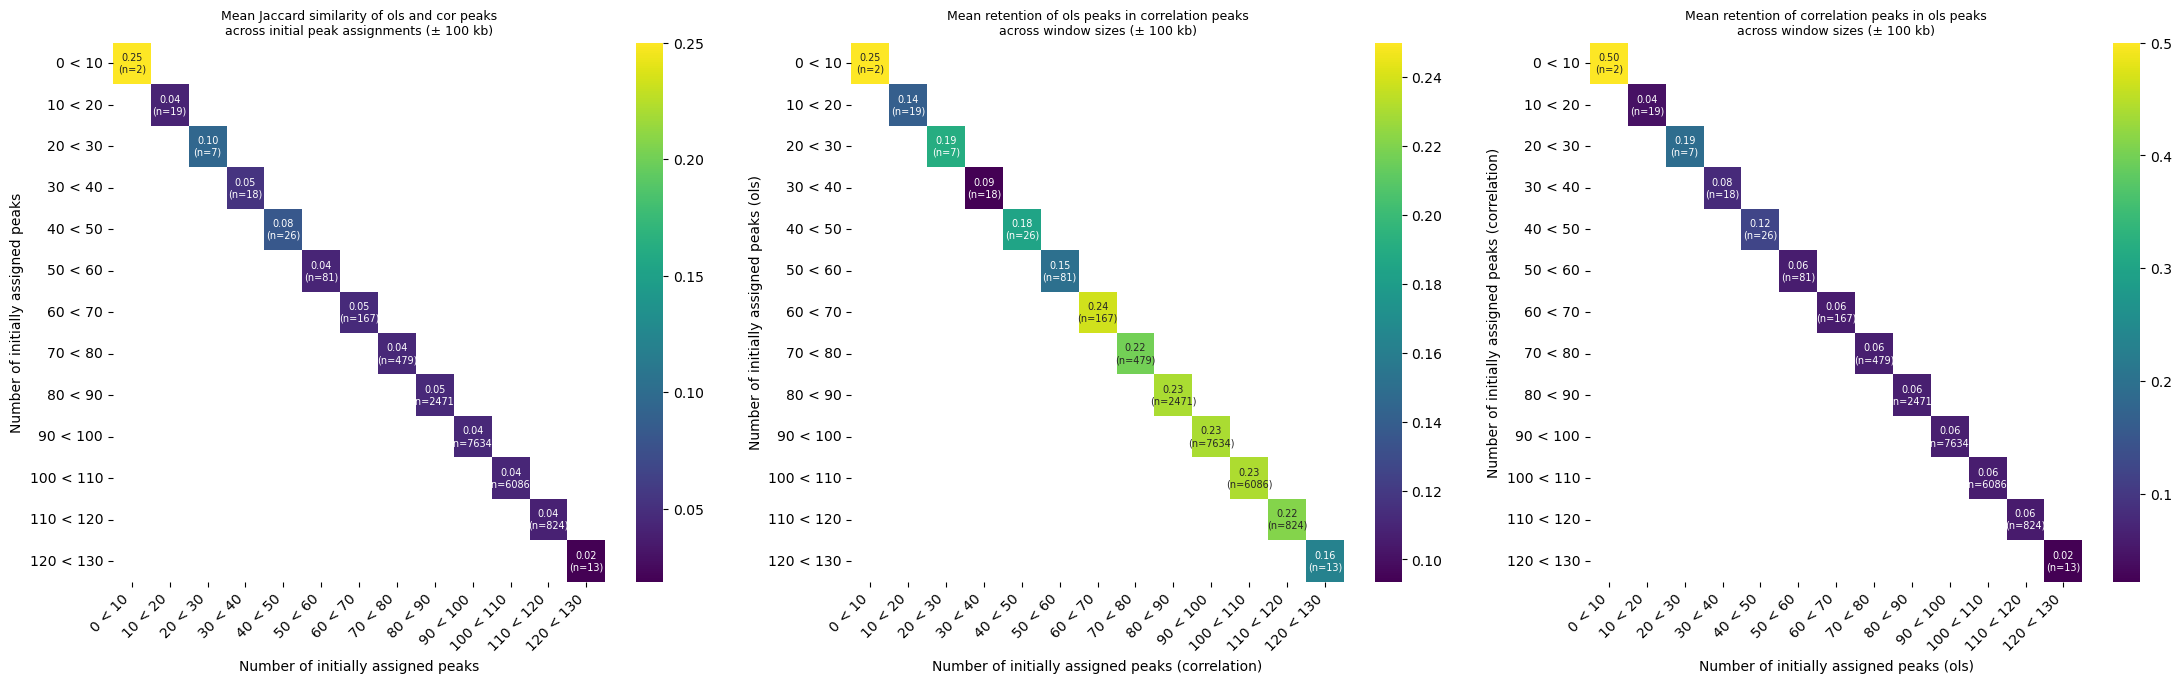

<Figure size 640x480 with 0 Axes>

In [18]:
#defining a function to create annotation strings for the heatmap, including the mean value and the number of genes that contributed to that mean value for each cell in the matrix
def make_annot(matrix, counts):
    annot = matrix.copy().astype(object)
    for w1 in matrix.index:
        for w2 in matrix.columns:
            val = matrix.loc[w1, w2]
            n = counts.loc[w1, w2]
            if pd.isna(val):
                annot.loc[w1, w2] = ""
            else:
                n_int = int(n) if not pd.isna(n) else 0
                annot.loc[w1, w2] = f"{val:.2f}\n(n={n_int})"
    return annot

import matplotlib.pyplot as plt
import seaborn as sns

window_labels = ['0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120', '120 < 130']

# --- counts for each comparison ---
jaccard_counts = jaccard_long.pivot_table(
    index="w1", columns="w2", values="jaccard", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)

retention_counts_oc = retention_long_oc.pivot_table(
    index="w1", columns="w2", values="retention", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)

retention_counts_co = retention_long_co.pivot_table(
    index="w1", columns="w2", values="retention", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)


# --- annotation strings ---
jaccard_annot = make_annot(jaccard_matrix, jaccard_counts)
retention_annot_oc = make_annot(retention_matrix_oc, retention_counts_oc)
retention_annot_co = make_annot(retention_matrix_co, retention_counts_co)

# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(27, 7))
#make annotation size smaller
sns.heatmap(jaccard_matrix.astype(float), annot=jaccard_annot.values, annot_kws={"size": 7}, fmt="", cmap="viridis", ax=axes[0]) #make annotation size smaller
axes[0].set_xticklabels( jaccard_annot.columns, rotation=45, ha="right")
axes[0].set_xlabel("Number of initially assigned peaks")
axes[0].set_ylabel("Number of initially assigned peaks")
axes[0].set_title("Mean Jaccard similarity of ols and cor peaks\nacross initial peak assignments (± 100 kb)", fontsize=9)

sns.heatmap(retention_matrix_oc.astype(float), annot=retention_annot_oc.values, annot_kws={"size": 7}, fmt="", cmap="viridis", ax=axes[1])
axes[1].set_xticklabels( retention_annot_oc.columns, rotation=45, ha="right")
axes[1].set_xlabel("Number of initially assigned peaks (correlation)")
axes[1].set_ylabel("Number of initially assigned peaks (ols)")
axes[1].set_title("Mean retention of ols peaks in correlation peaks\nacross window sizes (± 100 kb)", fontsize=9)

sns.heatmap(retention_matrix_co.astype(float), annot=retention_annot_co.values, annot_kws={"size": 7}, fmt="", cmap="viridis", ax=axes[2])
axes[2].set_xticklabels( retention_annot_co.columns, rotation=45, ha="right")
axes[2].set_xlabel("Number of initially assigned peaks (ols)")
axes[2].set_ylabel("Number of initially assigned peaks (correlation)")
axes[2].set_title("Mean retention of correlation peaks in ols peaks\nacross window sizes (± 100 kb)", fontsize=9)

plt.show()
plt.tight_layout()

In [19]:
#how to make counts matrix from long format df
counts_matrix = jaccard_long.pivot_table(
    index="w1", columns="w2", values="jaccard", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)

#how to make mean matrix from long format df
mean_matrix = jaccard_long.pivot_table(
    index="w1", columns="w2", values="jaccard", aggfunc="mean"
).reindex(index=window_labels, columns=window_labels)

In [20]:
#save the results of long format dataframes 
jaccard_long.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/ct_time/jaccard_long_100kb.csv", index=False)
retention_long_oc.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/ct_time/retention_long_oc_100kb.csv", index=False)
retention_long_co.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/ct_time/retention_long_co_100kb.csv", index=False)


In [21]:
#load the dataframes back in to check if they are saved correctly
import pandas as pd
jaccard_long = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/ct_time/jaccard_long_100kb.csv")
retention_long_oc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/ct_time/retention_long_oc_100kb.csv")
retention_long_co = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/ct_time/retention_long_co_100kb.csv")

In [22]:
jaccard_long.head()
retention_long_oc.head()
retention_long_co.head()

,w1,w2,gene,retention
0,0 < 10,0 < 10,si:ch211-207e19.2,1.0
1,0 < 10,0 < 10,zgc:174275,0.0
2,10 < 20,10 < 20,si:dkey-51d8.9,0.4
3,10 < 20,10 < 20,zgc:173720,0.0
4,10 < 20,10 < 20,si:ch211-226o13.1,0.0


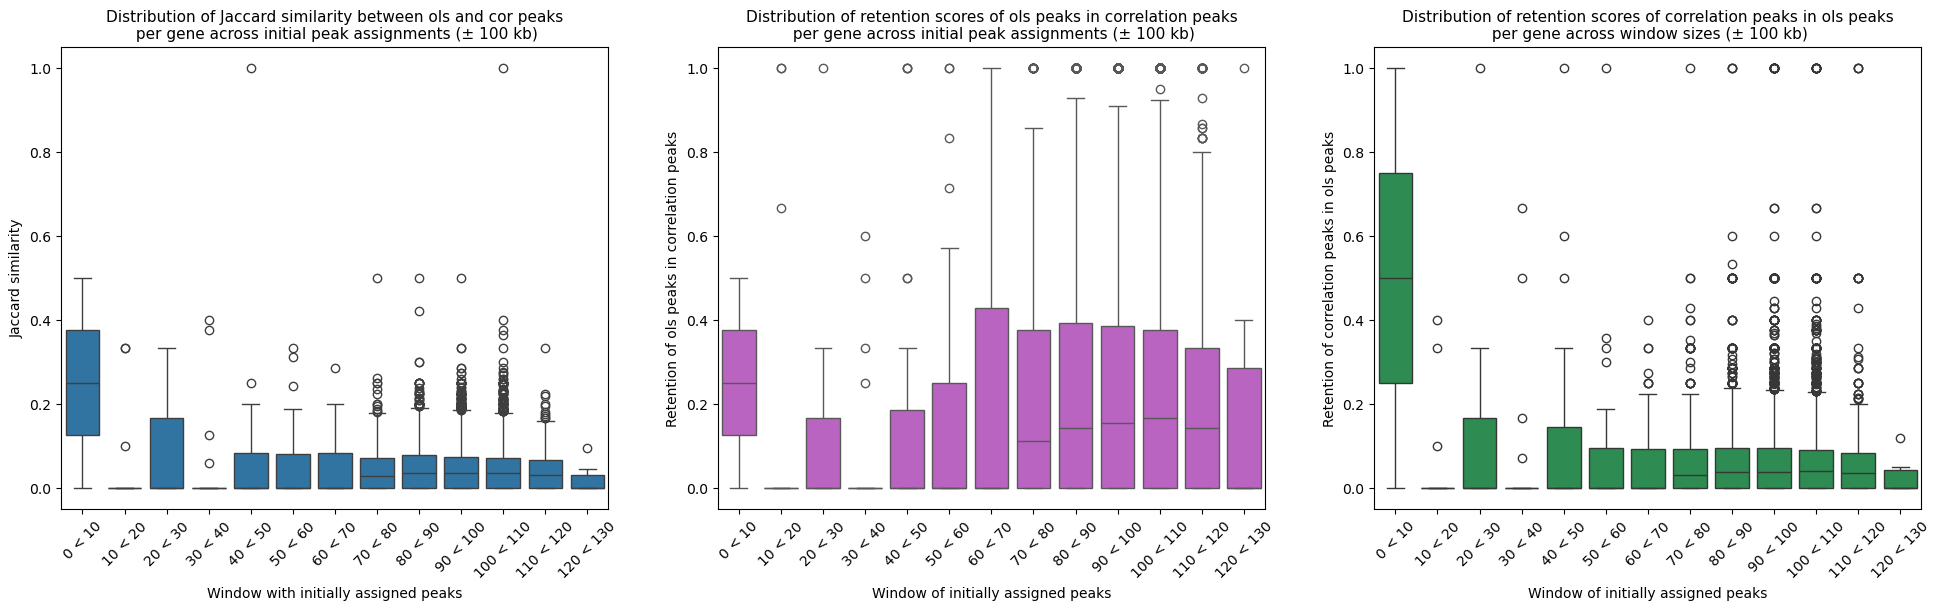

<Figure size 640x480 with 0 Axes>

In [33]:
#plot boxplots of the jaccard similarity and retention values for each pair of window sizes, using the long format dataframes
import matplotlib.pyplot as plt
import seaborn as sns   


fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.boxplot(x="w1", y="jaccard", data=jaccard_long, ax=axes[0])
axes[0].tick_params(axis='x', rotation=45)

#negative log scale the y-axis of the jaccard similarity plot to better visualize the distribution of values, since many values are close to 0
axes[0].set_xlabel("Window with initially assigned peaks")
axes[0].set_ylabel("Jaccard similarity")
axes[0].set_title("Distribution of Jaccard similarity between ols and cor peaks\n per gene across initial peak assignments (± 100 kb)", fontsize=11)

sns.boxplot(x="w1", y="retention", data=retention_long_oc, color= "#c755d1", ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
#axes[1].set_yscale('log')
axes[1].set_xlabel("Window of initially assigned peaks") 
axes[1].set_ylabel("Retention of ols peaks in correlation peaks")
axes[1].set_title("Distribution of retention scores of ols peaks in correlation peaks\n per gene across initial peak assignments (± 100 kb)", fontsize=11)

sns.boxplot(x="w1", y="retention", data=retention_long_co, color ="#1e9b4e", ax=axes[2])
axes[2].tick_params(axis='x', rotation=45)
#axes[2].set_yscale('log')
axes[2].set_xlabel("Window of initially assigned peaks") 
axes[2].set_ylabel("Retention of correlation peaks in ols peaks")
axes[2].set_title("Distribution of retention scores of correlation peaks in ols peaks\n per gene across window sizes (± 100 kb)", fontsize=11)

plt.show()
plt.tight_layout()


In [26]:
#combine retention dataframes into one long format dataframe for easier plotting
retention_long_oc["comparison"] = "OLS -> Correlation"
retention_long_co["comparison"] = "Correlation -> OLS"
retention_long_combined = pd.concat([retention_long_oc, retention_long_co], ignore_index=True)
retention_long_combined.head()

,w1,w2,gene,retention,comparison
0,0 < 10,0 < 10,si:ch211-207e19.2,0.500000,OLS -> Correlation
1,0 < 10,0 < 10,zgc:174275,0.000000,OLS -> Correlation
2,10 < 20,10 < 20,si:dkey-51d8.9,0.666667,OLS -> Correlation
3,10 < 20,10 < 20,zgc:173720,0.000000,OLS -> Correlation
4,10 < 20,10 < 20,si:ch211-226o13.1,0.000000,OLS -> Correlation


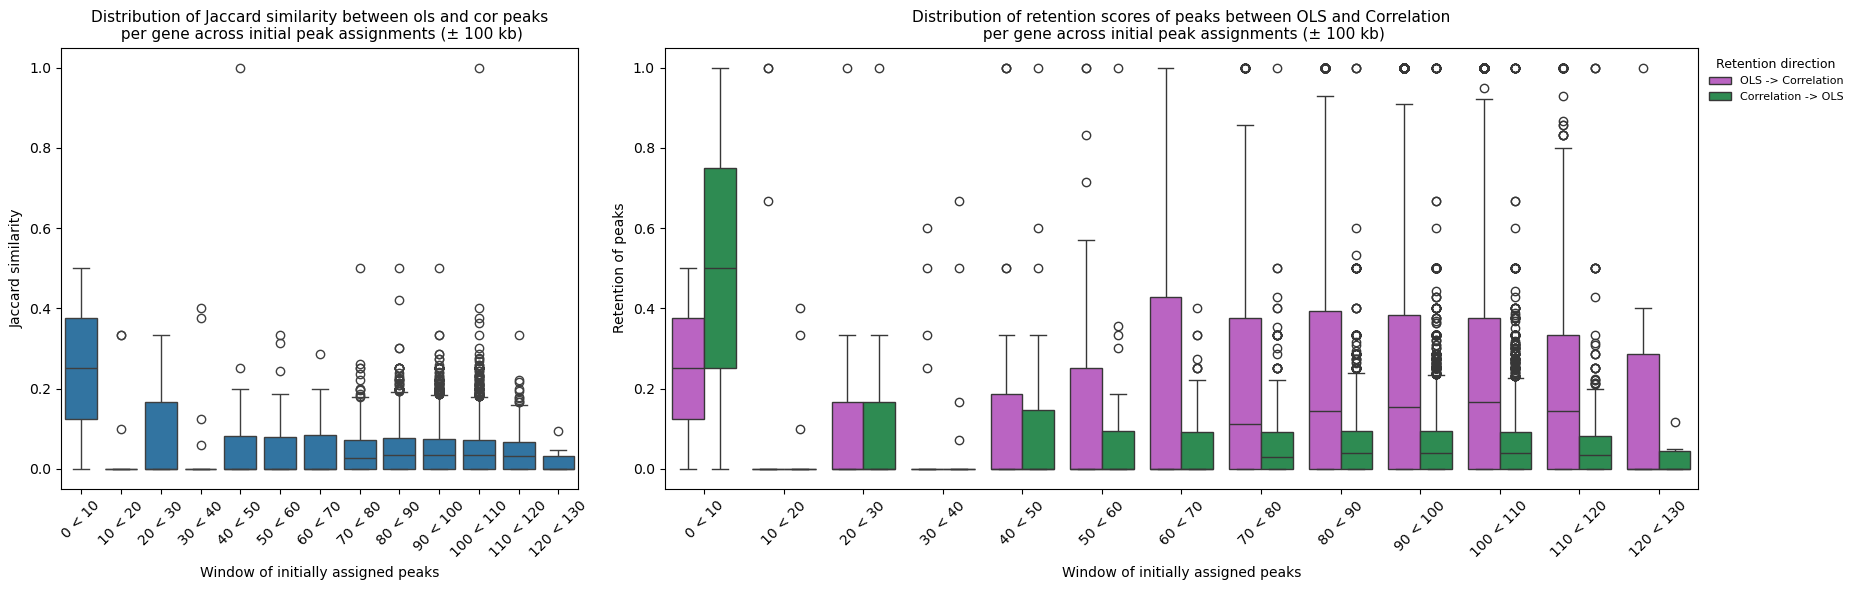

In [38]:
#plot boxplots of the jaccard similarity and retention values for each pair of window sizes, using the long format dataframes
import matplotlib.pyplot as plt
import seaborn as sns   


fig, axes = plt.subplots(1,2, figsize=(18, 6), gridspec_kw={'width_ratios': [1, 2]})

sns.boxplot(x="w1", y="jaccard", data=jaccard_long, ax=axes[0])
#make the plot quadratic
plt.subplots_adjust(wspace=1.2)
axes[0].tick_params(axis='x', rotation=45)
#negative log scale the y-axis of the jaccard similarity plot to better visualize the distribution of values, since many values are close to 0
#axes[0].set_yscale('log')
axes[0].set_xlabel("Window of initially assigned peaks")
axes[0].set_ylabel("Jaccard similarity")
axes[0].set_title("Distribution of Jaccard similarity between ols and cor peaks\n per gene across initial peak assignments (± 100 kb)", fontsize=11)

method_colors = {"Correlation -> OLS": "#1e9b4e", "OLS -> Correlation": "#c755d1"}

sns.boxplot(x="w1", y="retention", hue="comparison", data=retention_long_combined, palette=method_colors)
plt.xticks(rotation=45)
plt.xlabel("Window of initially assigned peaks")
plt.ylabel("Retention of peaks")
plt.title("Distribution of retention scores of peaks between OLS and Correlation\n per gene across initial peak assignments (± 100 kb)", fontsize=11)
plt.legend(title="Retention direction", loc="upper right", fontsize=8, title_fontsize=9, bbox_to_anchor=(1.15, 1), frameon=False)
plt.tight_layout()
plt.show()



# Categorize the retention scores to see better distribution withing each assigned peaks window

In [56]:
#add a category column, by classifying the retention similarity values into three categories: "low" for values < 0.25, "moderate" for values between 0.25 and 0.50, and "high" for values between 0.75 and very high for values > 0.75
def classify_retention(value):
    if value < 0.25:
        return "low"
    elif 0.25 <= value < 0.50:
        return "moderate"
    elif 0.50 <= value < 0.75:
        return "high"
    else:
        return "very high"

retention_long_oc["category"] = retention_long_oc["retention"].apply(classify_retention)
retention_long_co["category"] = retention_long_co["retention"].apply(classify_retention)
print(retention_long_oc.head())
retention_long_co.head()    

  ols_peak_count_window cor_peak_count_window               gene  retention  \
0                0 < 10                0 < 10  si:ch211-207e19.2   0.500000   
1                0 < 10                0 < 10         zgc:174275   0.000000   
2               10 < 20               10 < 20     si:dkey-51d8.9   0.666667   
3               10 < 20               10 < 20         zgc:173720   0.000000   
4               10 < 20               10 < 20  si:ch211-226o13.1   0.000000   

           comparison category  
0  OLS -> Correlation     high  
1  OLS -> Correlation      low  
2  OLS -> Correlation     high  
3  OLS -> Correlation      low  
4  OLS -> Correlation      low  


,cor_peak_count_window,ols_peak_count_window,gene,retention,comparison,category
0,0 < 10,0 < 10,si:ch211-207e19.2,1.0,Correlation -> OLS,very high
1,0 < 10,0 < 10,zgc:174275,0.0,Correlation -> OLS,low
2,10 < 20,10 < 20,si:dkey-51d8.9,0.4,Correlation -> OLS,moderate
3,10 < 20,10 < 20,zgc:173720,0.0,Correlation -> OLS,low
4,10 < 20,10 < 20,si:ch211-226o13.1,0.0,Correlation -> OLS,low


In [57]:
#rename the column w1 to ols_peak_count_window and w2 to cor_peak_count_window in both retention_long_oc and retention_long_co dataframes
retention_long_oc = retention_long_oc.rename(columns={"w1": "ols_peak_count_window", "w2": "cor_peak_count_window"})
retention_long_co = retention_long_co.rename(columns={"w1": "cor_peak_count_window", "w2": "ols_peak_count_window"})
print(retention_long_oc.head())
print(retention_long_co.head())

  ols_peak_count_window cor_peak_count_window               gene  retention  \
0                0 < 10                0 < 10  si:ch211-207e19.2   0.500000   
1                0 < 10                0 < 10         zgc:174275   0.000000   
2               10 < 20               10 < 20     si:dkey-51d8.9   0.666667   
3               10 < 20               10 < 20         zgc:173720   0.000000   
4               10 < 20               10 < 20  si:ch211-226o13.1   0.000000   

           comparison category  
0  OLS -> Correlation     high  
1  OLS -> Correlation      low  
2  OLS -> Correlation     high  
3  OLS -> Correlation      low  
4  OLS -> Correlation      low  
  cor_peak_count_window ols_peak_count_window               gene  retention  \
0                0 < 10                0 < 10  si:ch211-207e19.2        1.0   
1                0 < 10                0 < 10         zgc:174275        0.0   
2               10 < 20               10 < 20     si:dkey-51d8.9        0.4   
3          

In [58]:
#aggregate the number of significant peaks per gene and category  
agg_retention_oc = (
    retention_long_oc
    .dropna(subset=["gene", "retention", "category"]) #
    .groupby(["ols_peak_count_window","cor_peak_count_window", "category"]) 
    .size()
    .reset_index(name="count")
)

agg_retention_co = (
    retention_long_co
    .dropna(subset=["gene", "retention", "category"])
    .groupby(["cor_peak_count_window", "ols_peak_count_window", "category"])
    .size()
    .reset_index(name="count")
)

In [59]:
agg_retention_oc.head()

,ols_peak_count_window,cor_peak_count_window,category,count
0,0 < 10,0 < 10,high,1
1,0 < 10,0 < 10,low,1
2,10 < 20,10 < 20,high,1
3,10 < 20,10 < 20,low,16
4,10 < 20,10 < 20,very high,2


In [60]:
#merge the aggregated dataframes for positive and negative windows to compare the number of significant peaks per gene and category across windows
agg_retention_all = pd.concat(
    [agg_retention_oc.assign(retention="oc"),
     agg_retention_co.assign(retention="co")],
    ignore_index=True
)
agg_retention_all.head()

,ols_peak_count_window,cor_peak_count_window,category,count,retention
0,0 < 10,0 < 10,high,1,oc
1,0 < 10,0 < 10,low,1,oc
2,10 < 20,10 < 20,high,1,oc
3,10 < 20,10 < 20,low,16,oc
4,10 < 20,10 < 20,very high,2,oc


In [61]:
#counting the number of retention scores per gene and category across windows for both oc and co retention scores
significant_peaks_count = agg_retention_all.groupby(["cor_peak_count_window", "ols_peak_count_window", "retention"])["count"].sum().reset_index(name="total_count")
significant_peaks_count.head()

,cor_peak_count_window,ols_peak_count_window,retention,total_count
0,0 < 10,0 < 10,co,2
1,0 < 10,0 < 10,oc,2
2,10 < 20,10 < 20,co,19
3,10 < 20,10 < 20,oc,19
4,100 < 110,100 < 110,co,6086


In [62]:
#sanity check: how many genes have 0-10 peaks in both ols and cor datasets, and what is their retention category?
agg_retention_all[(agg_retention_all["retention"] == "oc") & (agg_retention_all["ols_peak_count_window"] == "0-10") & (agg_retention_all["cor_peak_count_window"] == "0-10")]

,ols_peak_count_window,cor_peak_count_window,category,count,retention


In [63]:
#add total_count column to the agg_retention_all dataframe by merging with the significant_peaks_count dataframe on cor_peak_count_window, ols_peak_count_window, and retention columns
agg_retention_all = agg_retention_all.merge(
    significant_peaks_count,
    on=["cor_peak_count_window", "ols_peak_count_window", "retention"],
    how="left"
)
agg_retention_all.head()

,ols_peak_count_window,cor_peak_count_window,category,count,retention,total_count
0,0 < 10,0 < 10,high,1,oc,2
1,0 < 10,0 < 10,low,1,oc,2
2,10 < 20,10 < 20,high,1,oc,19
3,10 < 20,10 < 20,low,16,oc,19
4,10 < 20,10 < 20,very high,2,oc,19


In [64]:
#calculate the fraction of categories within one count_window by dividing the total_count by the count of each category in that window and category separately for oc and co retention scores
agg_retention_all["fraction"] = agg_retention_all["count"]/ agg_retention_all["total_count"]


agg_retention_all.head()

,ols_peak_count_window,cor_peak_count_window,category,count,retention,total_count,fraction
0,0 < 10,0 < 10,high,1,oc,2,0.500000
1,0 < 10,0 < 10,low,1,oc,2,0.500000
2,10 < 20,10 < 20,high,1,oc,19,0.052632
3,10 < 20,10 < 20,low,16,oc,19,0.842105
4,10 < 20,10 < 20,very high,2,oc,19,0.105263


In [65]:
#sort the dataframe by the window_order column to ensure the windows are in the correct order for visualization
agg_retention_all = agg_retention_all.sort_values("ols_peak_count_window")
agg_retention_all.head()

,ols_peak_count_window,cor_peak_count_window,category,count,retention,total_count,fraction
0,0 < 10,0 < 10,high,1,oc,2,0.500000
46,0 < 10,0 < 10,low,1,co,2,0.500000
47,0 < 10,0 < 10,very high,1,co,2,0.500000
1,0 < 10,0 < 10,low,1,oc,2,0.500000
3,10 < 20,10 < 20,low,16,oc,19,0.842105


In [66]:
#sanity check: confirm that the fraction column sums to 1 for each window and category across both directions
fraction_sums = agg_retention_all.groupby(["ols_peak_count_window","retention"])["fraction"].sum().reset_index()
print(fraction_sums[fraction_sums["fraction"] != 1.0])

Empty DataFrame
Columns: [ols_peak_count_window, retention, fraction]
Index: []


In [67]:
#make window columns categorical with the correct order for visualization
window_order = ['0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120', '120 < 130']
agg_retention_all["ols_peak_count_window"] = pd.Categorical(agg_retention_all["ols_peak_count_window"], categories=window_order, ordered=True)
agg_retention_all["cor_peak_count_window"] = pd.Categorical(agg_retention_all["cor_peak_count_window"], categories=window_order, ordered=True)
agg_retention_all.head()    

,ols_peak_count_window,cor_peak_count_window,category,count,retention,total_count,fraction
0,0 < 10,0 < 10,high,1,oc,2,0.500000
46,0 < 10,0 < 10,low,1,co,2,0.500000
47,0 < 10,0 < 10,very high,1,co,2,0.500000
1,0 < 10,0 < 10,low,1,oc,2,0.500000
3,10 < 20,10 < 20,low,16,oc,19,0.842105


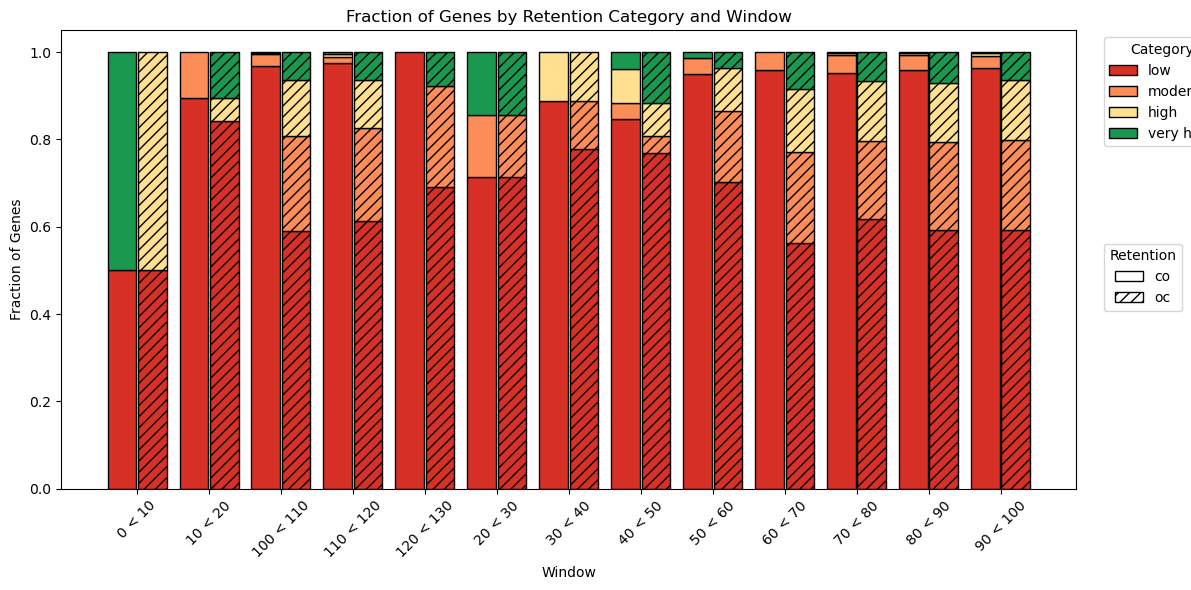

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

plot_df = agg_retention_all.copy()

category_order = ["low", "moderate", "high", "very high"]
categories_color_map = {
    "low": "#d73027",
    "moderate": "#fc8d59",
    "high": "#fee090",
    "very high": "#1a9850"
}

# pull window order from window_order col if present, else fall back to natural sort
if 'window_order' in plot_df.columns:
    windows = (plot_df[['ols_peak_count_window', 'window_order']]
               .drop_duplicates()
               .sort_values('window_order')['ols_peak_count_window']
               .tolist())
else:
    windows = sorted(plot_df['ols_peak_count_window'].unique())

retention_cat = sorted(plot_df['retention'].unique())  # e.g. ['co', 'oc']
hatches = ['', '///']

bar_width = 0.8 / len(retention_cat)
offsets = (np.arange(len(retention_cat)) - (len(retention_cat) - 1) / 2) * (bar_width + 0.02)
x_positions = np.arange(len(windows))

fig, ax = plt.subplots(figsize=(12, 6))

for i, retention in enumerate(retention_cat):
    ret_data = plot_df[plot_df['retention'] == retention]
    for j, window in enumerate(windows):
        win_data = ret_data[ret_data['ols_peak_count_window'] == window]
        if win_data.empty:
            continue
        # enforce low -> very high stacking order explicitly
        win_data = (win_data.set_index('category')
                    .reindex(category_order)
                    .dropna(subset=['fraction']))
        total = win_data['fraction'].sum()
        bottom = 0
        x_pos = x_positions[j] + offsets[i]
        for cat, row in win_data.iterrows():
            frac = row['fraction'] / total
            ax.bar(
                x_pos, frac, width=bar_width, bottom=bottom,
                color=categories_color_map[cat],
                edgecolor='black',
                hatch=hatches[i]
            )
            bottom += frac

ax.set_xticks(x_positions)
ax.set_xticklabels(windows, rotation=45)
ax.set_xlabel('Window')
ax.set_ylabel('Fraction of Genes')
ax.set_title('Fraction of Genes by Retention Category and Window')

category_handles = [Patch(facecolor=categories_color_map[c], edgecolor='black', label=c)
                    for c in category_order]
retention_handles = [Patch(facecolor='white', edgecolor='black', hatch=hatches[i], label=retention_cat[i])
                     for i in range(len(retention_cat))]

legend1 = ax.legend(handles=category_handles, title='Category', loc='upper left', bbox_to_anchor=(1.02, 1))
ax.add_artist(legend1)
ax.legend(handles=retention_handles, title='Retention', loc='upper left', bbox_to_anchor=(1.02, 0.55))

plt.tight_layout()
plt.show()